# Lecture A05: Estimands and Estimators

Companion notebook for [[Lecture A05 - Estimands & Estiplans]]. Prerequisites: [[A01|A01]] through [[A04|A04]].

**Part 1** — Lecture walkthrough: estimand/estimator/estimate distinction, total causal effect (no height control), posterior means vs posterior predictions vs contrasts, direct causal effect (condition on height), centering, bowtie contrast plot

**Part 2** — Applied exercises with Slovenian data: total vs direct effect of property type on price, forensic category contrasts (mean vs predictive), municipality total/direct/mediation decomposition, bowtie plots for real estate and forensic audio

**Convention:** 89% credible intervals (McElreath default).

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy import stats, optimize
from pathlib import Path

SEED = 42
rng = np.random.default_rng(SEED)

plt.rcParams.update({
    "figure.facecolor": "white",
    "axes.facecolor": "white",
    "savefig.dpi": 150,
    "figure.dpi": 150,
    "font.size": 11,
    "axes.titlesize": 12,
    "axes.labelsize": 11,
})

C_PRIOR = "#9ca3af"
C_POSTERIOR = "#2563eb"
C_LIKELIHOOD = "#dc2626"
C_DATA = "#059669"
C_ACCENT = "#d97706"
C_POINT = "#111827"
C_FEMALE = "#dc2626"
C_MALE = "#2563eb"
C_PURPLE = "#7c3aed"

DATA_DIR = Path("../data")
CI_LEVEL = 0.89
N_SAMPLES = 10_000

---

# Part 1: Lecture Walkthrough

## 1. Estimand, Estimator, Estimate

| Term | Definition |
|------|-----------|
| **Estimand** | The formal scientific question: $P(W \mid \text{do}(S))$ |
| **Estimator** | The recipe: statistical model + fitting procedure |
| **Estimate** | The result: a posterior distribution, a contrast |

Different estimands from the same DAG require different estimators. The DAG is fixed; the estimand determines the model.

**DAG:** $S \rightarrow H \rightarrow W$, $S \rightarrow W$ (two paths from sex to weight)

## 2. Generative Model and True Causal Effects

Simulate interventions to establish the ground truth before fitting any model.

In [2]:
def sim_hw(sex: np.ndarray, alpha: np.ndarray, beta: np.ndarray, seed: int = SEED) -> dict:
    """Simulate height-weight data from the S -> H -> W, S -> W DAG.

    Args:
        sex: Array of sex indices (1=female, 2=male).
        alpha: Intercepts per sex, shape (2,).
        beta: Slopes per sex, shape (2,).
        seed: Random seed.

    Returns:
        Dict with S, H, W arrays.
    """
    rng = np.random.default_rng(seed)
    n = len(sex)
    sex_idx = sex - 1
    h_mean = np.where(sex == 1, 150, 160)
    h = h_mean + rng.normal(0, 5, size=n)
    w = alpha[sex_idx] + beta[sex_idx] * h + rng.normal(0, 5, size=n)
    return {"S": sex, "H": h, "W": w}

TRUE_ALPHA = np.array([-20.0, -25.0])
TRUE_BETA = np.array([0.5, 0.6])

# Intervene: set everyone to female vs male
sim_f = sim_hw(np.ones(1000, dtype=int), TRUE_ALPHA, TRUE_BETA, seed=1)
sim_m = sim_hw(np.full(1000, 2, dtype=int), TRUE_ALPHA, TRUE_BETA, seed=1)

true_total = np.mean(sim_m["W"]) - np.mean(sim_f["W"])
print(f"True total causal effect (male - female): {true_total:.2f} kg")
print(f"  This includes both paths: S->H->W (stature) and S->W (body composition)")

# True direct effect at mean height
h_bar = 155  # approximate population mean
true_direct = (TRUE_ALPHA[1] + TRUE_BETA[1] * h_bar) - (TRUE_ALPHA[0] + TRUE_BETA[0] * h_bar)
print(f"\nTrue direct effect at height={h_bar}: {true_direct:.2f} kg")
print(f"  Indirect component (through stature): {true_total - true_direct:.2f} kg")

True total causal effect (male - female): 15.97 kg
  This includes both paths: S->H->W (stature) and S->W (body composition)

True direct effect at height=155: 10.50 kg
  Indirect component (through stature): 5.47 kg


## 3. Estimand 1: Total Causal Effect of Sex on Weight

$$P(W \mid \text{do}(S))$$

Do NOT condition on height. This captures both the direct path ($S \rightarrow W$) and the indirect path ($S \rightarrow H \rightarrow W$).

$$W_i \sim \text{Normal}(\alpha_{S[i]}, \sigma)$$

In [3]:
# Generate observed data
rng_obs = np.random.default_rng(SEED)
sex_obs = rng_obs.choice([1, 2], size=200)
dat = sim_hw(sex_obs, TRUE_ALPHA, TRUE_BETA)

# Fit total effect model: W ~ Normal(alpha[S], sigma)
def quap_total(weights, sex):
    """Fit total effect model and return posterior samples."""
    sex_idx = sex - 1
    def neg_lp(params):
        a1, a2, log_s = params
        sigma = np.exp(log_s)
        alpha = np.array([a1, a2])
        mu = alpha[sex_idx]
        ll = np.sum(stats.norm.logpdf(weights, mu, sigma))
        lp = stats.norm.logpdf(a1, 60, 10) + stats.norm.logpdf(a2, 60, 10) + log_s
        return -(ll + lp)

    x0 = np.array([60.0, 70.0, np.log(8.0)])
    result = optimize.minimize(neg_lp, x0, method="Nelder-Mead")
    eps = 1e-5
    hess = np.zeros((3, 3))
    for i in range(3):
        def gi(x, _i=i): return optimize.approx_fprime(x, neg_lp, eps)[_i]
        hess[i] = optimize.approx_fprime(result.x, gi, eps)
    cov = np.linalg.inv(hess)
    rng = np.random.default_rng(SEED)
    samp = rng.multivariate_normal(result.x, cov, size=N_SAMPLES)
    return {"a1": samp[:, 0], "a2": samp[:, 1], "sigma": np.exp(samp[:, 2]),
            "mode": result.x}

fit_total = quap_total(dat["W"], dat["S"])
print("Total effect model: W ~ Normal(alpha[S], sigma)")
print(f"  alpha_female = {fit_total['a1'].mean():.2f} +/- {fit_total['a1'].std():.2f}")
print(f"  alpha_male   = {fit_total['a2'].mean():.2f} +/- {fit_total['a2'].std():.2f}")
print(f"  sigma        = {fit_total['sigma'].mean():.2f}")

Total effect model: W ~ Normal(alpha[S], sigma)
  alpha_female = 55.34 +/- 0.55
  alpha_male   = 70.61 +/- 0.54
  sigma        = 5.46


## 4. Three Distributions, Three Questions

The three panels from the lecture:
1. **Marginal posteriors**: what is each group's average weight?
2. **Mean contrast** ($\alpha_2 - \alpha_1$): how much heavier is the average man?
3. **Weight contrast** (including $\sigma$): if I pick a random man and woman, who is heavier?

Never compare distributions by eyeballing overlap. Always compute the contrast.

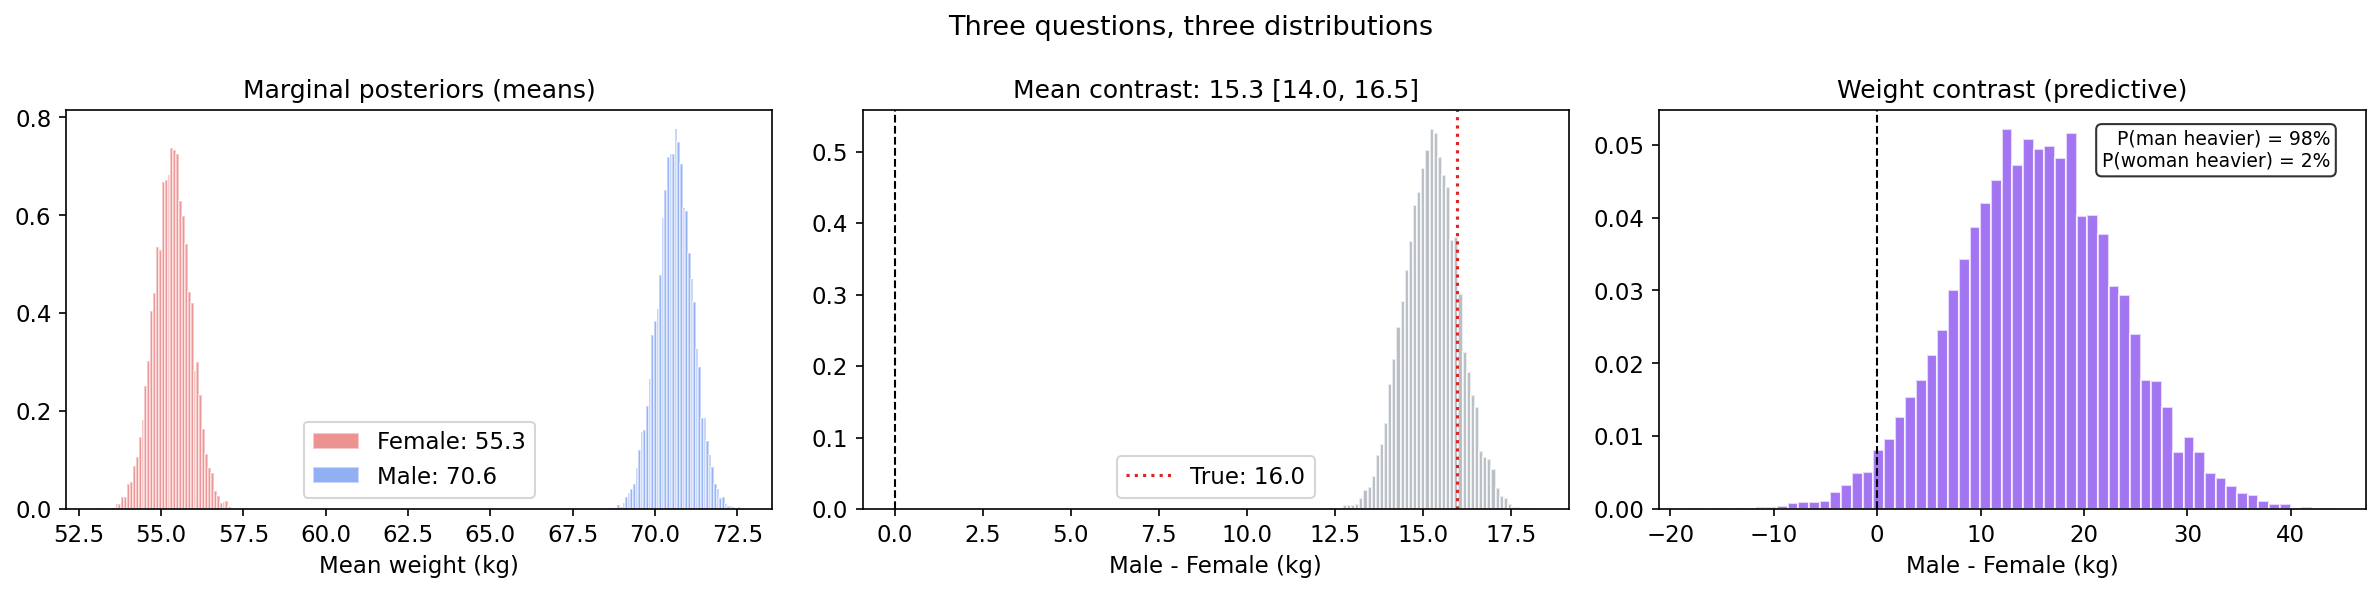

Mean contrast is narrow (about averages). Weight contrast is wide (about individuals).
You cannot get P(man heavier)=98% from eyeballing marginal overlap.


In [4]:
fig, axes = plt.subplots(1, 3, figsize=(16, 4))
rng_c = np.random.default_rng(SEED)

# Panel 1: Marginal posteriors
axes[0].hist(fit_total["a1"], bins=50, density=True, alpha=0.5, color=C_FEMALE,
             edgecolor="white", label=f"Female: {fit_total['a1'].mean():.1f}")
axes[0].hist(fit_total["a2"], bins=50, density=True, alpha=0.5, color=C_MALE,
             edgecolor="white", label=f"Male: {fit_total['a2'].mean():.1f}")
axes[0].set_title("Marginal posteriors (means)")
axes[0].set_xlabel("Mean weight (kg)")
axes[0].legend()

# Panel 2: Mean contrast
mu_contrast = fit_total["a2"] - fit_total["a1"]
ci = np.percentile(mu_contrast, [5.5, 94.5])
axes[1].hist(mu_contrast, bins=50, density=True, alpha=0.7, color=C_PRIOR, edgecolor="white")
axes[1].axvline(0, color="black", linestyle="--", linewidth=1)
axes[1].axvline(true_total, color=C_LIKELIHOOD, linestyle=":", linewidth=1.5, label=f"True: {true_total:.1f}")
axes[1].set_title(f"Mean contrast: {mu_contrast.mean():.1f} [{ci[0]:.1f}, {ci[1]:.1f}]")
axes[1].set_xlabel("Male - Female (kg)")
axes[1].legend()

# Panel 3: Weight contrast (predictive — includes sigma)
w_f = rng_c.normal(fit_total["a1"], fit_total["sigma"])
w_m = rng_c.normal(fit_total["a2"], fit_total["sigma"])
w_contrast = w_m - w_f
prop_m_heavier = (w_contrast > 0).mean()

axes[2].hist(w_contrast, bins=60, density=True, alpha=0.7, color=C_PURPLE, edgecolor="white")
axes[2].axvline(0, color="black", linestyle="--", linewidth=1)
axes[2].set_title(f"Weight contrast (predictive)")
axes[2].set_xlabel("Male - Female (kg)")
axes[2].text(0.95, 0.95, f"P(man heavier) = {prop_m_heavier:.0%}\nP(woman heavier) = {1-prop_m_heavier:.0%}",
             transform=axes[2].transAxes, ha="right", va="top", fontsize=9,
             bbox=dict(boxstyle="round", facecolor="white", alpha=0.8))

plt.suptitle("Three questions, three distributions", fontsize=13)
plt.tight_layout()
plt.show()

print(f"Mean contrast is narrow (about averages). Weight contrast is wide (about individuals).")
print(f"You cannot get P(man heavier)={prop_m_heavier:.0%} from eyeballing marginal overlap.")

## 5. Estimand 2: Direct Causal Effect of Sex on Weight

$$P(W \mid \text{do}(S), H = h)$$

Condition on height to block $S \rightarrow H \rightarrow W$. What remains is body composition.

**Centering:** replace $H_i$ with $(H_i - \bar{H})$ so the intercept means "expected weight at average height."

$$\mu_i = \alpha_{S[i]} + \beta_{S[i]}(H_i - \bar{H})$$

In [5]:
# Fit direct effect model: W ~ alpha[S] + beta[S] * (H - H_bar)
def quap_direct(weights, heights, sex):
    """Fit direct effect model with centered height, stratified slopes."""
    sex_idx = sex - 1
    h_bar = heights.mean()
    hc = heights - h_bar

    def neg_lp(params):
        a1, a2, b1, b2, log_s = params
        sigma = np.exp(log_s)
        alpha = np.array([a1, a2])
        beta = np.array([b1, b2])
        mu = alpha[sex_idx] + beta[sex_idx] * hc
        ll = np.sum(stats.norm.logpdf(weights, mu, sigma))
        lp = (stats.norm.logpdf(a1, 60, 10) + stats.norm.logpdf(a2, 60, 10)
              + stats.uniform.logpdf(b1, 0, 1) + stats.uniform.logpdf(b2, 0, 1)
              + log_s)
        return -(ll + lp)

    x0 = np.array([55.0, 65.0, 0.5, 0.6, np.log(5.0)])
    result = optimize.minimize(neg_lp, x0, method="Nelder-Mead", options={"maxiter": 20_000})
    eps = 1e-5
    hess = np.zeros((5, 5))
    for i in range(5):
        def gi(x, _i=i): return optimize.approx_fprime(x, neg_lp, eps)[_i]
        hess[i] = optimize.approx_fprime(result.x, gi, eps)
    cov = np.linalg.inv(hess)
    rng = np.random.default_rng(SEED)
    samp = rng.multivariate_normal(result.x, cov, size=N_SAMPLES)
    samp[:, 4] = np.exp(samp[:, 4])
    return {"samples": samp, "h_bar": h_bar, "mode": result.x}

fit_direct = quap_direct(dat["W"], dat["H"], dat["S"])
s = fit_direct["samples"]
print("Direct effect model: W ~ alpha[S] + beta[S] * (H - H_bar)")
print(f"  alpha_female = {s[:, 0].mean():.2f} (weight at avg height, female)")
print(f"  alpha_male   = {s[:, 1].mean():.2f} (weight at avg height, male)")
print(f"  beta_female  = {s[:, 2].mean():.3f}")
print(f"  beta_male    = {s[:, 3].mean():.3f}")
print(f"  sigma        = {s[:, 4].mean():.2f}")
print(f"  H_bar        = {fit_direct['h_bar']:.1f} cm")

direct_contrast_at_mean = s[:, 0] - s[:, 1]
ci_d = np.percentile(direct_contrast_at_mean, [5.5, 94.5])
print(f"\nDirect effect at mean height: {direct_contrast_at_mean.mean():.2f} [{ci_d[0]:.2f}, {ci_d[1]:.2f}] kg")

Direct effect model: W ~ alpha[S] + beta[S] * (H - H_bar)
  alpha_female = 57.59 (weight at avg height, female)
  alpha_male   = 68.87 (weight at avg height, male)
  beta_female  = 0.505
  beta_male    = 0.402
  sigma        = 5.07
  H_bar        = 154.9 cm

Direct effect at mean height: -11.29 [-12.94, -9.63] kg


## 6. The Bowtie Plot: Contrast as a Function of Height

The direct effect varies with height. At each height, compute $\mu_F(h) - \mu_M(h)$ from joint posterior samples. Uncertainty is smallest near $\bar{H}$ (where centering anchors) and grows toward the extremes.

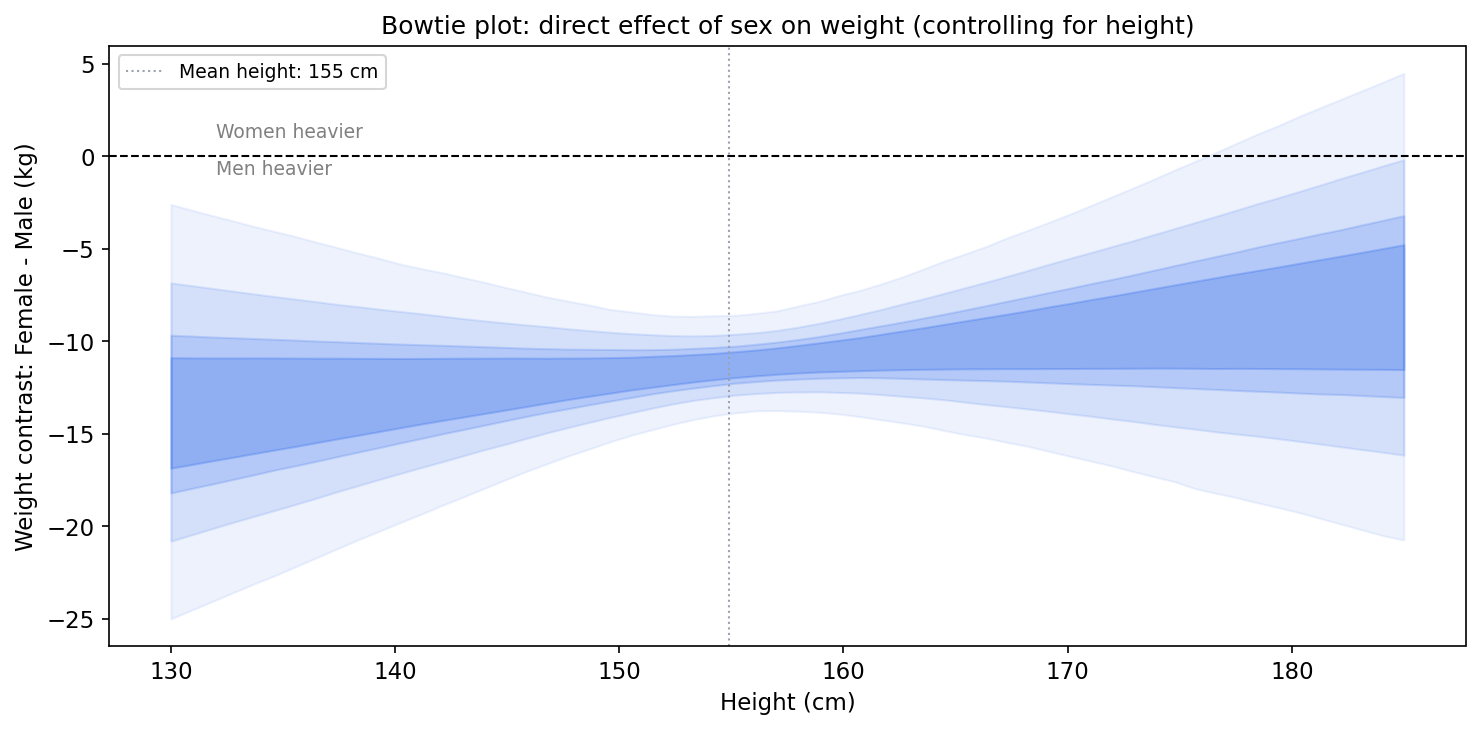

Narrowest at mean height (centering anchor). Widens at extremes (extrapolation).
Below zero everywhere: men heavier at every height (body composition effect).


In [6]:
# Bowtie plot
h_seq = np.linspace(130, 185, 60)
hc = h_seq - fit_direct["h_bar"]
samp = fit_direct["samples"]

mu_f = samp[:, 0:1] + samp[:, 2:3] * hc[None, :]
mu_m = samp[:, 1:2] + samp[:, 3:4] * hc[None, :]
contrast = mu_f - mu_m  # female - male

fig, ax = plt.subplots(figsize=(10, 5))

for prob, alpha_val in [(0.99, 0.08), (0.89, 0.12), (0.67, 0.18), (0.50, 0.25)]:
    lo = np.percentile(contrast, (1 - prob) / 2 * 100, axis=0)
    hi = np.percentile(contrast, (1 + prob) / 2 * 100, axis=0)
    ax.fill_between(h_seq, lo, hi, alpha=alpha_val, color=C_POSTERIOR)

ax.axhline(0, linestyle="--", color="black", linewidth=1)
ax.axvline(fit_direct["h_bar"], linestyle=":", color=C_PRIOR, linewidth=1, label=f"Mean height: {fit_direct['h_bar']:.0f} cm")
ax.set_xlabel("Height (cm)")
ax.set_ylabel("Weight contrast: Female - Male (kg)")
ax.set_title("Bowtie plot: direct effect of sex on weight (controlling for height)")
ax.text(132, -1, "Men heavier", fontsize=9, color="gray")
ax.text(132, 1, "Women heavier", fontsize=9, color="gray")
ax.legend(fontsize=9)
plt.tight_layout()
plt.show()

print("Narrowest at mean height (centering anchor). Widens at extremes (extrapolation).")
print("Below zero everywhere: men heavier at every height (body composition effect).")

---

# Part 2: Applied Exercises with Slovenian Data

The estimand-to-estimate pipeline applied to real datasets. All real estate scoped to 2022+.

In [7]:
# Load datasets
re = pd.read_csv(DATA_DIR / "sr2026_real_estate.csv", parse_dates=["date"])
forensic = pd.read_csv(DATA_DIR / "sr2026_forensic_audio.csv")
mun = pd.read_csv(DATA_DIR / "sr2026_municipality_panel.csv")

YEAR_MIN = 2022
re_apt = re[
    (re["year"] >= YEAR_MIN)
    & (re["property_type"].isin(["apartment", "detached_house"]))
    & re["price_per_m2"].notna() & re["area_m2"].notna()
    & (re["area_m2"] > 10) & (re["area_m2"] < 300)
    & (re["price_eur"] > 5_000) & (re["price_eur"] < 1_000_000)
].copy()

print(f"Real estate ({YEAR_MIN}+): {len(re_apt):,} (apartments + houses)")
print(re_apt["property_type"].value_counts().to_string())

Real estate (2022+): 21,539 (apartments + houses)
property_type
apartment         15525
detached_house     6014


## Exercise 1: Total vs Direct Effect of Property Type on Price

**DAG:** $\text{Type} \rightarrow \text{Area}$, $\text{Type} \rightarrow \text{Price}$, $\text{Area} \rightarrow \text{Price}$

Two paths from type to price:
- **Indirect:** apartments tend to be smaller than houses, and smaller properties cost less
- **Direct:** type premium/discount independent of size

**Estimand 1 (total):** $P(\text{Price} \mid \text{do}(\text{Type}))$ — don't control for area

**Estimand 2 (direct):** $P(\text{Price} \mid \text{do}(\text{Type}), \text{Area}=a)$ — control for area

/tmp/ipykernel_2010764/3266034924.py:24: RuntimeWarning: covariance is not symmetric positive-semidefinite.
  samp = rng.multivariate_normal(res.x, cov, size=N_SAMPLES)
/tmp/ipykernel_2010764/3266034924.py:46: RuntimeWarning: covariance is not symmetric positive-semidefinite.
  samp = rng.multivariate_normal(res.x, cov, size=N_SAMPLES)


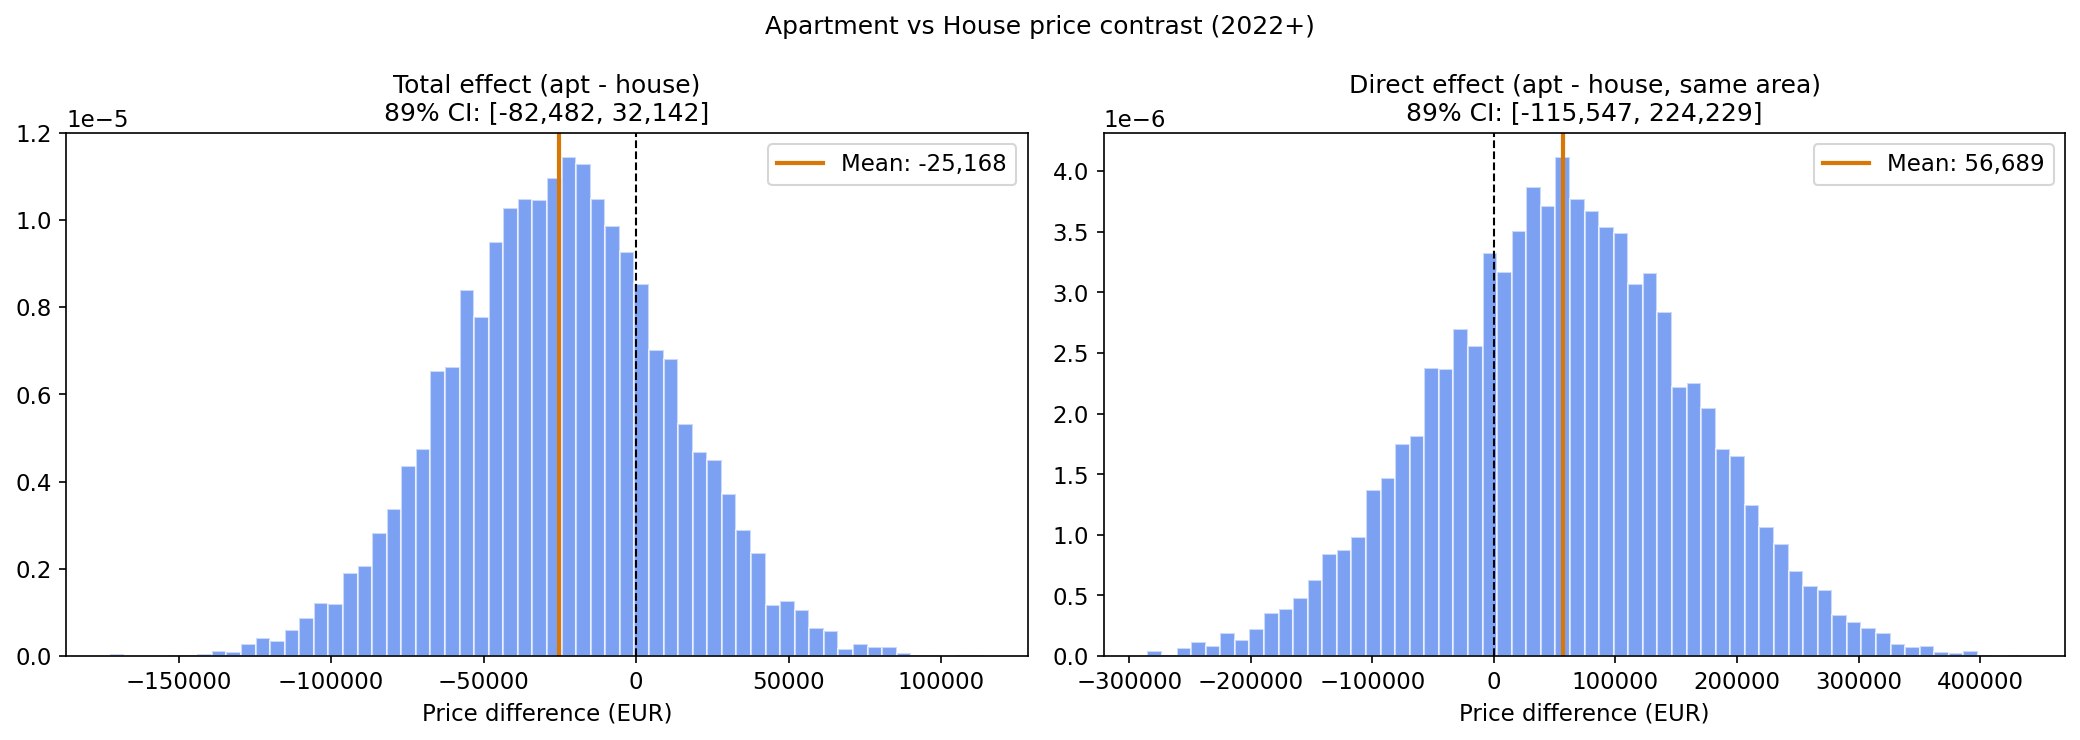

Total effect (apt - house):     -25,168 EUR
Direct effect (same area):       56,689 EUR
Indirect (through area):        -81,857 EUR

Apartments are smaller on avg (62 vs 144 m2).
The indirect component captures this size difference.


In [8]:
# Index: 0 = apartment, 1 = detached_house
type_map = {"apartment": 0, "detached_house": 1}
re_apt["tidx"] = re_apt["property_type"].map(type_map)
tidx = re_apt["tidx"].values
prices = re_apt["price_eur"].values
areas = re_apt["area_m2"].values

# --- Total effect: price ~ alpha[type] ---
def quap_2cat(y, idx):
    def neg_lp(params):
        a0, a1, log_s = params
        sigma = np.exp(log_s)
        mu = np.where(idx == 0, a0, a1)
        return -np.sum(stats.norm.logpdf(y, mu, sigma)) - log_s
    res = optimize.minimize(neg_lp, [np.mean(y), np.mean(y), np.log(np.std(y))],
                            method="Nelder-Mead")
    eps = 1e-4
    hess = np.zeros((3, 3))
    for i in range(3):
        def gi(x, _i=i): return optimize.approx_fprime(x, neg_lp, eps)[_i]
        hess[i] = optimize.approx_fprime(res.x, gi, eps)
    cov = np.linalg.inv(hess)
    rng = np.random.default_rng(SEED)
    samp = rng.multivariate_normal(res.x, cov, size=N_SAMPLES)
    return {"a0": samp[:, 0], "a1": samp[:, 1], "sigma": np.exp(samp[:, 2])}

# --- Direct effect: price ~ alpha[type] + beta * (area - area_bar) ---
def quap_2cat_direct(y, x, idx):
    x_bar = x.mean()
    xc = x - x_bar
    def neg_lp(params):
        a0, a1, beta, log_s = params
        sigma = np.exp(log_s)
        alpha = np.where(idx == 0, a0, a1)
        mu = alpha + beta * xc
        return -np.sum(stats.norm.logpdf(y, mu, sigma)) - log_s
    res = optimize.minimize(neg_lp, [np.mean(y), np.mean(y), 2000, np.log(np.std(y))],
                            method="Nelder-Mead", options={"maxiter": 20_000})
    eps = 1e-4
    hess = np.zeros((4, 4))
    for i in range(4):
        def gi(x, _i=i): return optimize.approx_fprime(x, neg_lp, eps)[_i]
        hess[i] = optimize.approx_fprime(res.x, gi, eps)
    cov = np.linalg.inv(hess)
    rng = np.random.default_rng(SEED)
    samp = rng.multivariate_normal(res.x, cov, size=N_SAMPLES)
    return {"a0": samp[:, 0], "a1": samp[:, 1], "beta": samp[:, 2],
            "sigma": np.exp(samp[:, 3]), "x_bar": x_bar}

fit_t = quap_2cat(prices, tidx)
fit_d = quap_2cat_direct(prices, areas, tidx)

# Total contrast
total_c = fit_t["a0"] - fit_t["a1"]
direct_c = fit_d["a0"] - fit_d["a1"]

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

for ax, contrast, title in zip(axes,
    [total_c, direct_c],
    ["Total effect (apt - house)", "Direct effect (apt - house, same area)"]):
    ci = np.percentile(contrast, [5.5, 94.5])
    ax.hist(contrast, bins=60, density=True, alpha=0.6, color=C_POSTERIOR, edgecolor="white")
    ax.axvline(0, color="black", linestyle="--", linewidth=1)
    ax.axvline(contrast.mean(), color=C_ACCENT, linewidth=2, label=f"Mean: {contrast.mean():,.0f}")
    ax.set_title(f"{title}\n89% CI: [{ci[0]:,.0f}, {ci[1]:,.0f}]")
    ax.set_xlabel("Price difference (EUR)")
    ax.legend()

plt.suptitle(f"Apartment vs House price contrast ({YEAR_MIN}+)", fontsize=12)
plt.tight_layout()
plt.show()

indirect = total_c.mean() - direct_c.mean()
print(f"Total effect (apt - house):  {total_c.mean():>10,.0f} EUR")
print(f"Direct effect (same area):   {direct_c.mean():>10,.0f} EUR")
print(f"Indirect (through area):     {indirect:>10,.0f} EUR")
print(f"\nApartments are smaller on avg ({re_apt[re_apt['tidx']==0]['area_m2'].mean():.0f} vs "
      f"{re_apt[re_apt['tidx']==1]['area_m2'].mean():.0f} m2).")
print("The indirect component captures this size difference.")

## Exercise 2: Forensic Audio — Mean Contrast vs Predictive Contrast

**Estimand:** How do authentic and manipulated recordings differ in ENF SNR?

Two contrasts:
- **Mean contrast** ($\alpha_{\text{auth}} - \alpha_{\text{manip}}$): difference in average ENF SNR
- **Predictive contrast** (including $\sigma$): probability that a random authentic recording has higher ENF SNR than a random manipulated one

The predictive contrast is what matters in casework: it quantifies individual-level discriminability.

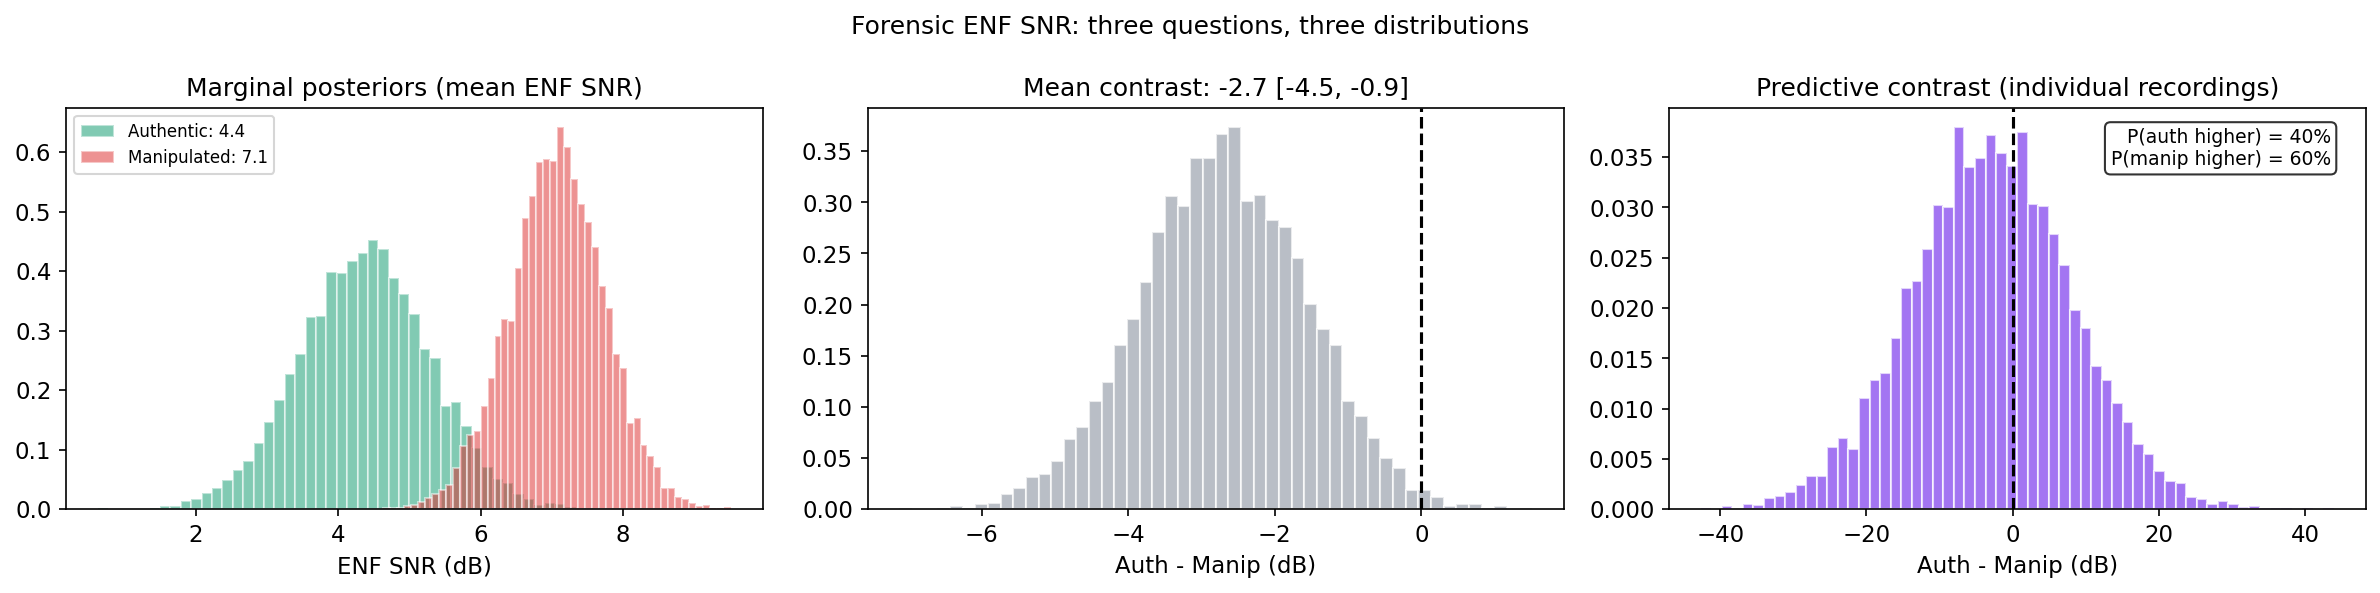

Mean contrast is narrow: average authentic ENF is -2.7 dB higher.
Predictive contrast is wide: individual discrimination is 40%.
The gap between these two numbers quantifies how much within-category variation limits forensic power.


In [9]:
# Authentic vs all-manipulated (binary)
forensic["is_manip"] = 1 - forensic["is_authentic"]
for_clean = forensic[forensic["enf_snr_50hz"].notna()].copy()

enf = for_clean["enf_snr_50hz"].values
aidx = for_clean["is_manip"].values  # 0=authentic, 1=manipulated

fit_for = quap_2cat(enf, aidx)

# Mean contrast
mu_c = fit_for["a0"] - fit_for["a1"]  # authentic - manipulated

# Predictive contrast
rng_for = np.random.default_rng(SEED)
w_auth = rng_for.normal(fit_for["a0"], fit_for["sigma"])
w_manip = rng_for.normal(fit_for["a1"], fit_for["sigma"])
pred_c = w_auth - w_manip

fig, axes = plt.subplots(1, 3, figsize=(16, 4))

# Marginals
axes[0].hist(fit_for["a0"], bins=50, density=True, alpha=0.5, color=C_DATA,
             edgecolor="white", label=f"Authentic: {fit_for['a0'].mean():.1f}")
axes[0].hist(fit_for["a1"], bins=50, density=True, alpha=0.5, color=C_LIKELIHOOD,
             edgecolor="white", label=f"Manipulated: {fit_for['a1'].mean():.1f}")
axes[0].set_title("Marginal posteriors (mean ENF SNR)")
axes[0].set_xlabel("ENF SNR (dB)")
axes[0].legend(fontsize=8)

# Mean contrast
ci_mu = np.percentile(mu_c, [5.5, 94.5])
axes[1].hist(mu_c, bins=50, density=True, alpha=0.7, color=C_PRIOR, edgecolor="white")
axes[1].axvline(0, color="black", linestyle="--")
axes[1].set_title(f"Mean contrast: {mu_c.mean():.1f} [{ci_mu[0]:.1f}, {ci_mu[1]:.1f}]")
axes[1].set_xlabel("Auth - Manip (dB)")

# Predictive contrast
prop_auth_higher = (pred_c > 0).mean()
axes[2].hist(pred_c, bins=60, density=True, alpha=0.7, color=C_PURPLE, edgecolor="white")
axes[2].axvline(0, color="black", linestyle="--")
axes[2].set_title("Predictive contrast (individual recordings)")
axes[2].set_xlabel("Auth - Manip (dB)")
axes[2].text(0.95, 0.95, f"P(auth higher) = {prop_auth_higher:.0%}\nP(manip higher) = {1-prop_auth_higher:.0%}",
             transform=axes[2].transAxes, ha="right", va="top", fontsize=9,
             bbox=dict(boxstyle="round", facecolor="white", alpha=0.8))

plt.suptitle("Forensic ENF SNR: three questions, three distributions", fontsize=12)
plt.tight_layout()
plt.show()

print(f"Mean contrast is narrow: average authentic ENF is {mu_c.mean():.1f} dB higher.")
print(f"Predictive contrast is wide: individual discrimination is {prop_auth_higher:.0%}.")
print("The gap between these two numbers quantifies how much within-category variation limits forensic power.")

## Exercise 3: Real Estate Bowtie — Type Premium as a Function of Area

**Estimand:** Direct effect of property type on price as a function of floor area.

$$\delta(a) = [\alpha_{\text{apt}} + \beta_{\text{apt}}(a - \bar{a})] - [\alpha_{\text{house}} + \beta_{\text{house}}(a - \bar{a})]$$

If the bowtie is flat, the type premium is constant across sizes. If it tilts, large and small properties have different premiums. This matters for CRR3 index segmentation.

/tmp/ipykernel_2010764/1393153551.py:31: RuntimeWarning: covariance is not symmetric positive-semidefinite.
  samp = rng.multivariate_normal(result.x, cov, size=N_SAMPLES)


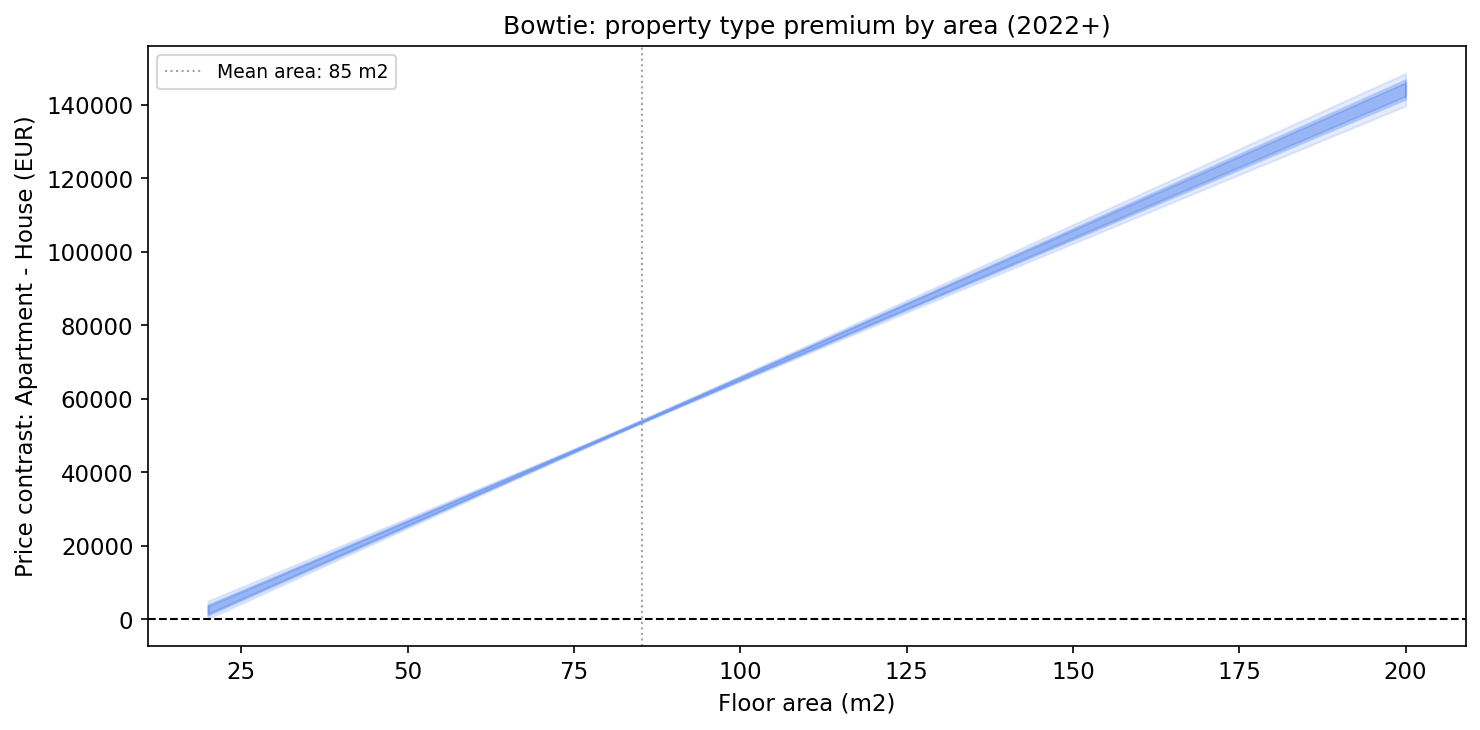

If the bowtie tilts, the apartment-house premium varies by property size.
Flat bowtie = constant premium. Tilted = size-dependent segmentation needed for CRR3.


In [10]:
# Fit stratified model: price ~ alpha[type] + beta[type] * (area - area_bar)
def quap_stratified(y, x, idx):
    """Fit model with stratified intercept AND slope."""
    x_bar = x.mean()
    xc = x - x_bar
    def neg_lp(params):
        a0, a1, b0, b1, log_s = params
        sigma = np.exp(log_s)
        alpha = np.where(idx == 0, a0, a1)
        beta = np.where(idx == 0, b0, b1)
        mu = alpha + beta * xc
        ll = np.sum(stats.norm.logpdf(y, mu, sigma))
        lp = (stats.norm.logpdf(a0, 150_000, 100_000) + stats.norm.logpdf(a1, 150_000, 100_000)
              + stats.norm.logpdf(b0, 2000, 2000) + stats.norm.logpdf(b1, 2000, 2000)
              + log_s)
        if sigma <= 0: return 1e12
        return -(ll + lp)

    x0 = np.array([np.mean(y), np.mean(y), 2000, 2000, np.log(np.std(y))])
    result = optimize.minimize(neg_lp, x0, method="Nelder-Mead", options={"maxiter": 20_000})
    eps = 1e-3
    hess = np.zeros((5, 5))
    for i in range(5):
        def gi(x, _i=i): return optimize.approx_fprime(x, neg_lp, eps)[_i]
        hess[i] = optimize.approx_fprime(result.x, gi, eps)
    try:
        cov = np.linalg.inv(hess)
    except np.linalg.LinAlgError:
        cov = np.eye(5) * 1000
    rng = np.random.default_rng(SEED)
    samp = rng.multivariate_normal(result.x, cov, size=N_SAMPLES)
    samp[:, 4] = np.exp(samp[:, 4])
    return {"samples": samp, "x_bar": x_bar}

fit_strat = quap_stratified(prices, areas, tidx)
ss = fit_strat["samples"]
area_seq = np.linspace(20, 200, 60)
ac = area_seq - fit_strat["x_bar"]

# Contrast at each area
mu_apt = ss[:, 0:1] + ss[:, 2:3] * ac[None, :]
mu_house = ss[:, 1:2] + ss[:, 3:4] * ac[None, :]
contrast_re = mu_apt - mu_house

fig, ax = plt.subplots(figsize=(10, 5))
for prob, alpha_val in [(0.89, 0.12), (0.67, 0.18), (0.50, 0.25)]:
    lo = np.percentile(contrast_re, (1 - prob) / 2 * 100, axis=0)
    hi = np.percentile(contrast_re, (1 + prob) / 2 * 100, axis=0)
    ax.fill_between(area_seq, lo, hi, alpha=alpha_val, color=C_POSTERIOR)

ax.axhline(0, linestyle="--", color="black", linewidth=1)
ax.axvline(fit_strat["x_bar"], linestyle=":", color=C_PRIOR, linewidth=1,
           label=f"Mean area: {fit_strat['x_bar']:.0f} m2")
ax.set_xlabel("Floor area (m2)")
ax.set_ylabel("Price contrast: Apartment - House (EUR)")
ax.set_title(f"Bowtie: property type premium by area ({YEAR_MIN}+)")
ax.legend(fontsize=9)
plt.tight_layout()
plt.show()

print("If the bowtie tilts, the apartment-house premium varies by property size.")
print("Flat bowtie = constant premium. Tilted = size-dependent segmentation needed for CRR3.")

## Exercise 4: Forensic Bowtie — Authenticity Contrast by Duration

**Estimand:** Direct effect of manipulation category on ENF SNR as a function of recording duration.

If the bowtie is flat near zero for authentic vs manipulated, ENF SNR does not discriminate well. If shifted and narrow, it is a strong forensic signal.

/tmp/ipykernel_2010764/1393153551.py:31: RuntimeWarning: covariance is not symmetric positive-semidefinite.
  samp = rng.multivariate_normal(result.x, cov, size=N_SAMPLES)


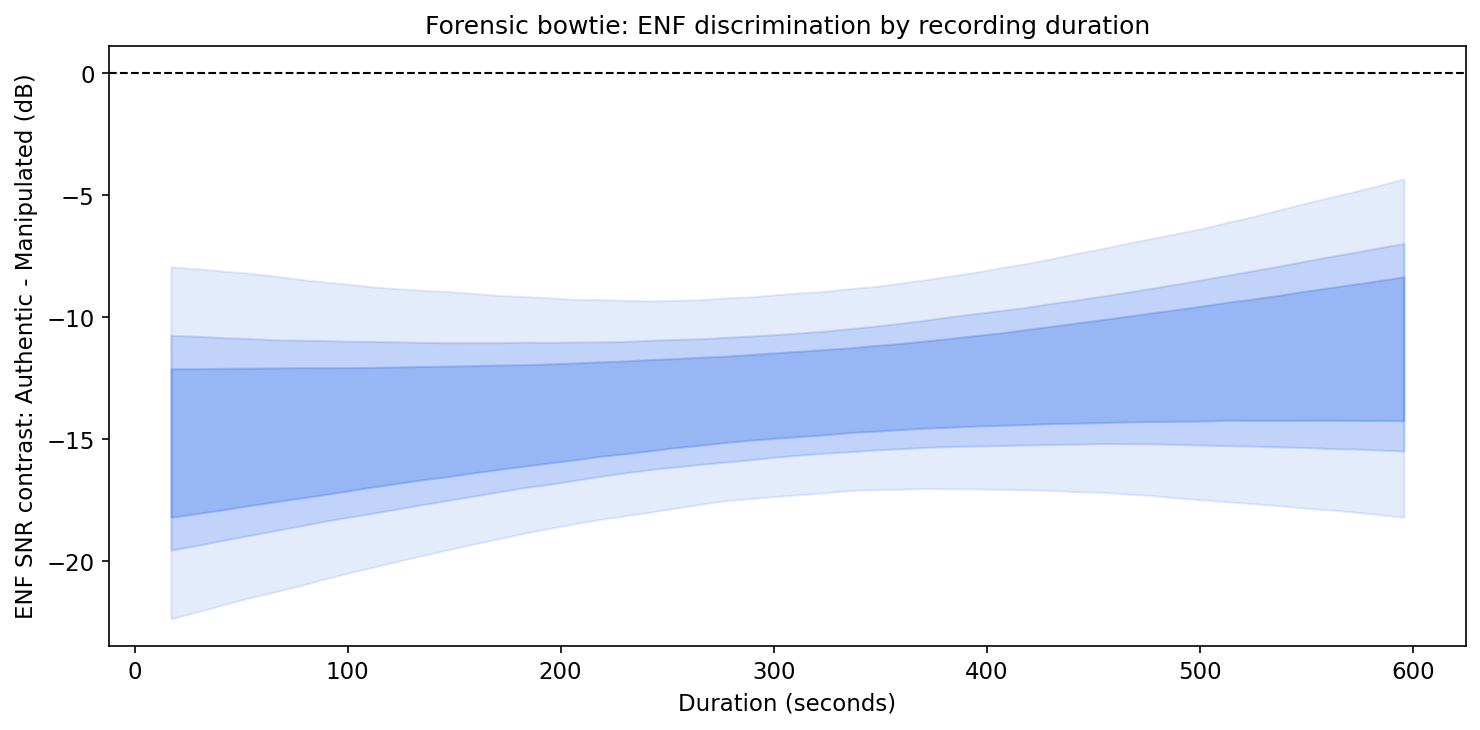

At median duration: auth - manip = -13.2 [-17.3, -9.0] dB
Positive = authentic has higher ENF SNR. Interval excluding zero = detectable signal.


In [11]:
# Binary: authentic (0) vs manipulated (1)
for_bt = forensic[forensic["enf_snr_50hz"].notna() & forensic["duration_s"].notna()].copy()
for_bt["midx"] = for_bt["is_manip"] = 1 - for_bt["is_authentic"]

enf_bt = for_bt["enf_snr_50hz"].values
dur_bt = for_bt["duration_s"].values
midx_bt = for_bt["midx"].values

fit_for_bt = quap_stratified(enf_bt, dur_bt, midx_bt)
ss_f = fit_for_bt["samples"]
dur_seq = np.linspace(dur_bt.min(), dur_bt.max(), 50)
dc = dur_seq - fit_for_bt["x_bar"]

mu_auth = ss_f[:, 0:1] + ss_f[:, 2:3] * dc[None, :]
mu_manip = ss_f[:, 1:2] + ss_f[:, 3:4] * dc[None, :]
contrast_for = mu_auth - mu_manip

fig, ax = plt.subplots(figsize=(10, 5))
for prob, alpha_val in [(0.89, 0.12), (0.67, 0.18), (0.50, 0.25)]:
    lo = np.percentile(contrast_for, (1 - prob) / 2 * 100, axis=0)
    hi = np.percentile(contrast_for, (1 + prob) / 2 * 100, axis=0)
    ax.fill_between(dur_seq, lo, hi, alpha=alpha_val, color=C_POSTERIOR)

ax.axhline(0, linestyle="--", color="black", linewidth=1)
ax.set_xlabel("Duration (seconds)")
ax.set_ylabel("ENF SNR contrast: Authentic - Manipulated (dB)")
ax.set_title("Forensic bowtie: ENF discrimination by recording duration")
plt.tight_layout()
plt.show()

mid_contrast = contrast_for[:, len(dur_seq)//2]
ci_mid = np.percentile(mid_contrast, [5.5, 94.5])
print(f"At median duration: auth - manip = {mid_contrast.mean():.1f} [{ci_mid[0]:.1f}, {ci_mid[1]:.1f}] dB")
print("Positive = authentic has higher ENF SNR. Interval excluding zero = detectable signal.")

---

# Key Takeaways

1. **Estimand determines the model.** Total effect of property type on price (don't control for area) vs direct effect (control for area) yield different contrasts from the same DAG. The indirect component (through area differences) quantifies mediation.

2. **Always compute the contrast.** Never eyeball marginal overlap. The mean contrast (narrow) and predictive contrast (wide) answer different questions. Forensic casework needs the predictive contrast: it gives P(authentic higher ENF) for individual recordings.

3. **Centering makes intercepts interpretable.** After centering area, the intercept means "expected price at average area" rather than "expected price for a 0 m2 property."

4. **Bowtie plots reveal heterogeneity.** The apartment-house premium may vary with area. The ENF discrimination may vary with duration. Plotting the contrast as a function of the continuous predictor (with nested CIs) shows where the effect is strong and where uncertain.

5. **Three distributions for three questions.** Marginal posteriors (what is each group's average?), mean contrast (how do averages differ?), predictive contrast (how do individuals differ?). Each serves a different stakeholder: CRR3 benchmarks need means, risk models need prediction intervals.

**Next:** [[Lecture A06]] introduces confounds (forks, pipes, colliders) and the rules for deciding what to control for.